# Decision Tree Classifier

In [1]:
%%capture
%%pip install hpsklearn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import utils
from utils import *
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, GridSearchCV
from sklearn.metrics import confusion_matrix, recall_score, roc_auc_score, roc_curve, precision_recall_curve
warnings.filterwarnings(action='ignore')

In [3]:
df = pd.read_csv('../../data/ACME-HappinessSurvey2020_shrunk.csv')
df.head()

,customer satisfaction,my order was delivered on time,contents of my order was as I expected,I ordered everything I wanted to order,I paid good price for my order,I am satisfied with my courier,the app makes ordering easy
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [4]:
y = df['customer satisfaction'].values
X = df.drop('customer satisfaction', axis=1)

In [5]:
seed = 5249

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.2,
    random_state=seed
)

In [6]:
kfold = KFold(10, shuffle=True, random_state=seed)

# for i, (train, test) in enumerate(kfold.split(X_train, y_train)):
#     print(i)
#     print(train)
#     print(test)

c = [len(test) for (train, test) in kfold.split(X_train, y_train)]

In [7]:
import math
from math import ceil

# maximum max_depth = log2(fold_length) where fold_length = 25 if using 4 fold CV with 100 total observations or in our case fold_length = 10 using 10 fold CV

print(f"Fold length: {c[0]}")

max_max_depth = ceil(np.log2(c[0]))
print(f"Maximum max_depth: {max_max_depth}")

dtc = DecisionTreeClassifier(max_depth=max_max_depth, random_state=seed, criterion='entropy')
dtc.fit(X_train, y_train)

Fold length: 10
Maximum max_depth: 4


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=5249)

In [8]:
return_scores(dtc, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.740000,0.709091,0.795918
Test,0.461538,0.285714,0.500000


[Text(0.4875, 0.9, 'my order was delivered on time <= 4.5\nentropy = 0.993\nsamples = 100\nvalue = [45.0, 55.0]'),
 Text(0.25, 0.7, 'I ordered everything I wanted to order <= 4.5\nentropy = 0.932\nsamples = 46\nvalue = [30, 16]'),
 Text(0.36875, 0.8, 'True  '),
 Text(0.2, 0.5, 'the app makes ordering easy <= 3.5\nentropy = 0.959\nsamples = 42\nvalue = [26, 16]'),
 Text(0.1, 0.3, 'I paid good price for my order <= 3.5\nentropy = 0.65\nsamples = 12\nvalue = [10, 2]'),
 Text(0.05, 0.1, 'entropy = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.15, 0.1, 'entropy = 0.863\nsamples = 7\nvalue = [5, 2]'),
 Text(0.3, 0.3, 'I am satisfied with my courier <= 4.5\nentropy = 0.997\nsamples = 30\nvalue = [16, 14]'),
 Text(0.25, 0.1, 'entropy = 0.992\nsamples = 29\nvalue = [16, 13]'),
 Text(0.35, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3, 0.5, 'entropy = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.725, 0.7, 'I ordered everything I wanted to order <= 3.5\nentropy = 0.852\nsamples = 54\

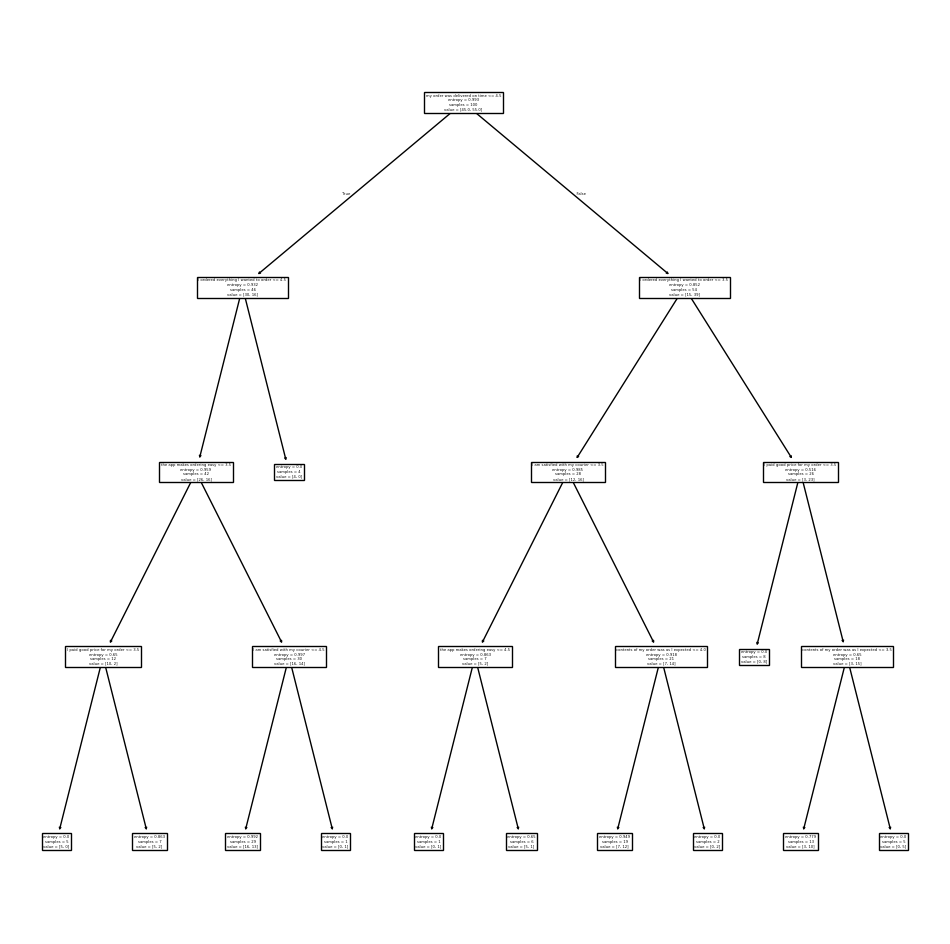

In [9]:
ax = plt.subplots(figsize=(12, 12))[1]

plot_tree(dtc,
          feature_names=X_train.columns,
          ax=ax
          )

In [10]:
print(export_text(dtc,
                  feature_names=X_train.columns,
                  show_weights=True
                  ))

|--- my order was delivered on time <= 4.50
|   |--- I ordered everything I wanted to order <= 4.50
|   |   |--- the app makes ordering easy <= 3.50
|   |   |   |--- I paid good price for my order <= 3.50
|   |   |   |   |--- weights: [5.00, 0.00] class: 0
|   |   |   |--- I paid good price for my order >  3.50
|   |   |   |   |--- weights: [5.00, 2.00] class: 0
|   |   |--- the app makes ordering easy >  3.50
|   |   |   |--- I am satisfied with my courier <= 4.50
|   |   |   |   |--- weights: [16.00, 13.00] class: 0
|   |   |   |--- I am satisfied with my courier >  4.50
|   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |--- I ordered everything I wanted to order >  4.50
|   |   |--- weights: [4.00, 0.00] class: 0
|--- my order was delivered on time >  4.50
|   |--- I ordered everything I wanted to order <= 3.50
|   |   |--- I am satisfied with my courier <= 3.50
|   |   |   |--- the app makes ordering easy <= 4.50
|   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |  

In [11]:
importance_df = pd.DataFrame({
    'Importance': dtc.feature_importances_
}, index=X_train.columns).sort_values(by='Importance', ascending=True)

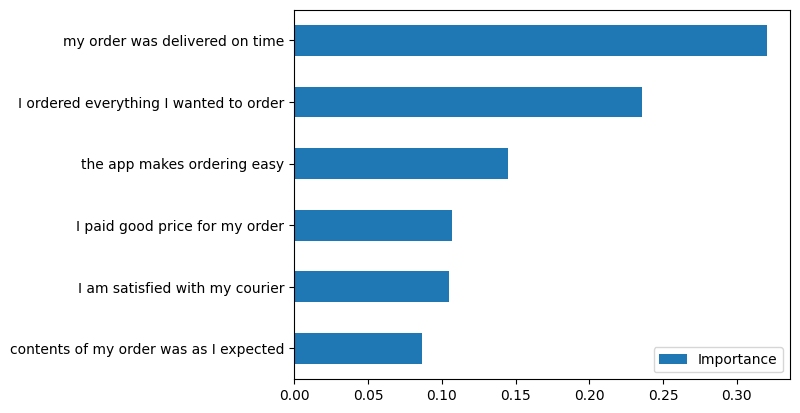

In [12]:
importance_df.plot(kind='barh')
plt.show()

In [13]:
ccp_path = dtc.cost_complexity_pruning_path(X_train, y_train)

In [14]:
ccp_path

{'ccp_alphas': array([0.        , 0.01128016, 0.01244624, 0.01568856, 0.01714217,
        0.01758425, 0.02141709, 0.02260331, 0.02561881, 0.02611233,
        0.05028872, 0.10370434]),
 'impurities': array([0.66888847, 0.68016864, 0.69261488, 0.70830344, 0.7254456 ,
        0.74302985, 0.76444695, 0.78705026, 0.81266907, 0.8387814 ,
        0.88907012, 0.99277445])}

In [18]:
from sklearn.model_selection import GridSearchCV

dtc = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=seed)

grid = GridSearchCV(dtc,
        {'ccp_alpha': ccp_path.ccp_alphas},
        refit=False,
        cv=kfold,
        scoring=['accuracy', 'recall'],
        # random_state=seed,
        return_train_score=True
        )
grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=5249, shuffle=True),
             estimator=DecisionTreeClassifier(criterion='entropy', max_depth=4,
                                              random_state=5249),
             param_grid={'ccp_alpha': array([0.        , 0.01128016, 0.01244624, 0.01568856, 0.01714217,
       0.01758425, 0.02141709, 0.02260331, 0.02561881, 0.02611233,
       0.05028872, 0.10370434])},
             refit=False, return_train_score=True,
             scoring=['accuracy', 'recall'])

In [19]:
grid_df = pd.DataFrame(grid.cv_results_)
grid_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,split2_train_recall,split3_train_recall,split4_train_recall,split5_train_recall,split6_train_recall,split7_train_recall,split8_train_recall,split9_train_recall,mean_train_recall,std_train_recall
0,0.015631,0.039050,0.005487,0.006930,0.000000,{'ccp_alpha': 0.0},0.4,0.5,0.4,0.8,...,0.739130,0.679245,0.58,0.74,0.74,0.980392,0.755102,0.877551,0.769771,0.111049
1,0.002858,0.000876,0.002934,0.000647,0.011280,{'ccp_alpha': 0.011280164365837064},0.4,0.5,0.5,0.8,...,0.782609,0.679245,0.58,0.74,0.74,0.980392,0.755102,0.877551,0.774119,0.110615
2,0.002322,0.000993,0.002875,0.000798,0.012446,{'ccp_alpha': 0.012446242227732579},0.6,0.5,0.5,0.8,...,0.782609,0.679245,0.56,0.72,0.74,0.980392,0.755102,0.877551,0.741548,0.115128
3,0.002034,0.000574,0.003143,0.001015,0.015689,{'ccp_alpha': 0.015688557048732663},0.6,0.5,0.5,0.8,...,0.782609,0.660377,0.56,0.72,0.74,0.980392,0.734694,0.877551,0.735537,0.116863
4,0.001938,0.000591,0.002754,0.000496,0.017142,{'ccp_alpha': 0.01714216590523257},0.6,0.5,0.5,0.8,...,0.782609,0.660377,0.70,0.72,0.70,0.980392,0.734694,0.877551,0.745537,0.103568


In [20]:
grid_df.sort_values(by='param_ccp_alpha', ascending=True, inplace=True)

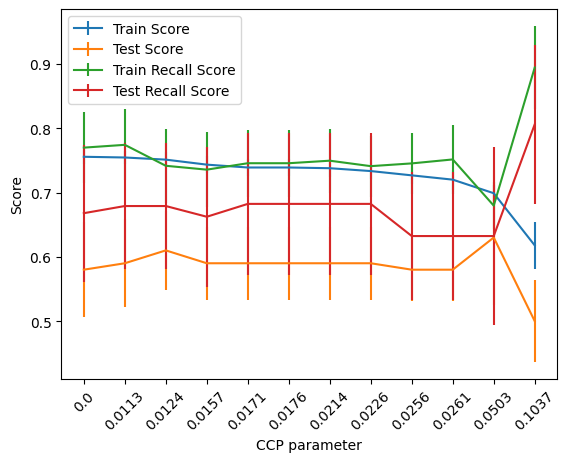

In [21]:
plt.errorbar(
    np.arange(len(grid_df['param_ccp_alpha'])),
    grid_df['mean_train_accuracy'],
    yerr=grid_df['std_train_accuracy']/np.sqrt(4),
    label='Train Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_ccp_alpha'])),
    grid_df['mean_test_accuracy'],
    yerr=grid_df['std_test_accuracy']/np.sqrt(4),
    label='Test Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_ccp_alpha'])),
    grid_df['mean_train_recall'],
    yerr=grid_df['std_train_recall']/np.sqrt(4),
    label='Train Recall Score'
    )
plt.errorbar(
    np.arange(len(grid_df['param_ccp_alpha'])),
    grid_df['mean_test_recall'],
    yerr=grid_df['std_test_recall']/np.sqrt(4),
    label='Test Recall Score'
    )
plt.xticks(np.arange(len(grid_df['param_ccp_alpha'])), round(grid_df['param_ccp_alpha'], 4), rotation=45)
plt.xlabel('CCP parameter')
plt.ylabel('Score')
plt.legend()
plt.show()

In [36]:
.0503+((.1037-.0503)/2)

0.077

[Text(0.453125, 0.9, 'my order was delivered on time <= 4.5\nentropy = 0.993\nsamples = 100\nvalue = [45.0, 55.0]'),
 Text(0.25, 0.7, 'I ordered everything I wanted to order <= 4.5\nentropy = 0.932\nsamples = 46\nvalue = [30, 16]'),
 Text(0.3515625, 0.8, 'True  '),
 Text(0.1875, 0.5, 'the app makes ordering easy <= 3.5\nentropy = 0.959\nsamples = 42\nvalue = [26, 16]'),
 Text(0.125, 0.3, 'I paid good price for my order <= 3.5\nentropy = 0.65\nsamples = 12\nvalue = [10, 2]'),
 Text(0.0625, 0.1, 'entropy = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.1875, 0.1, 'entropy = 0.863\nsamples = 7\nvalue = [5, 2]'),
 Text(0.25, 0.3, 'entropy = 0.997\nsamples = 30\nvalue = [16, 14]'),
 Text(0.3125, 0.5, 'entropy = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.65625, 0.7, 'I ordered everything I wanted to order <= 3.5\nentropy = 0.852\nsamples = 54\nvalue = [15, 39]'),
 Text(0.5546875, 0.8, '  False'),
 Text(0.5, 0.5, 'I am satisfied with my courier <= 3.5\nentropy = 0.985\nsamples = 28\nvalue = [12

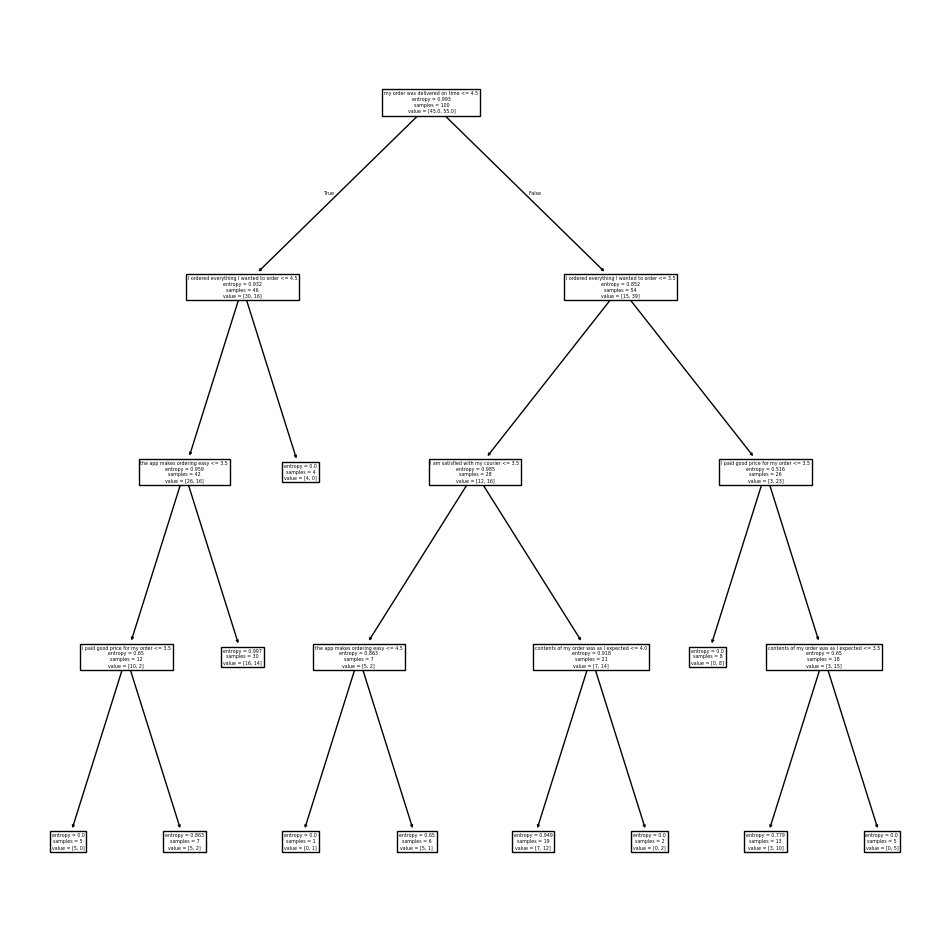

In [22]:
ax = plt.subplots(figsize=(12, 12))[1]

best_ = DecisionTreeClassifier(
    random_state=seed,
    criterion='entropy',
    ccp_alpha=.0124,
    max_depth=4
    ).fit(X_train, y_train)

plot_tree(best_,
feature_names=X_train.columns,
ax=ax)

In [23]:
print(export_text(best_,
                    feature_names=X_train.columns,
                    show_weights=True))

|--- my order was delivered on time <= 4.50
|   |--- I ordered everything I wanted to order <= 4.50
|   |   |--- the app makes ordering easy <= 3.50
|   |   |   |--- I paid good price for my order <= 3.50
|   |   |   |   |--- weights: [5.00, 0.00] class: 0
|   |   |   |--- I paid good price for my order >  3.50
|   |   |   |   |--- weights: [5.00, 2.00] class: 0
|   |   |--- the app makes ordering easy >  3.50
|   |   |   |--- weights: [16.00, 14.00] class: 0
|   |--- I ordered everything I wanted to order >  4.50
|   |   |--- weights: [4.00, 0.00] class: 0
|--- my order was delivered on time >  4.50
|   |--- I ordered everything I wanted to order <= 3.50
|   |   |--- I am satisfied with my courier <= 3.50
|   |   |   |--- the app makes ordering easy <= 4.50
|   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |--- the app makes ordering easy >  4.50
|   |   |   |   |--- weights: [5.00, 1.00] class: 0
|   |   |--- I am satisfied with my courier >  3.50
|   |   |   |--- conte

In [24]:
return_scores(best_, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.73,0.690909,0.791667
Test,0.50,0.285714,0.571429


In [25]:
best_coef_df = pd.DataFrame({
    'Importance': best_.feature_importances_
}, index=X_train.columns).sort_values('Importance', ascending=True)

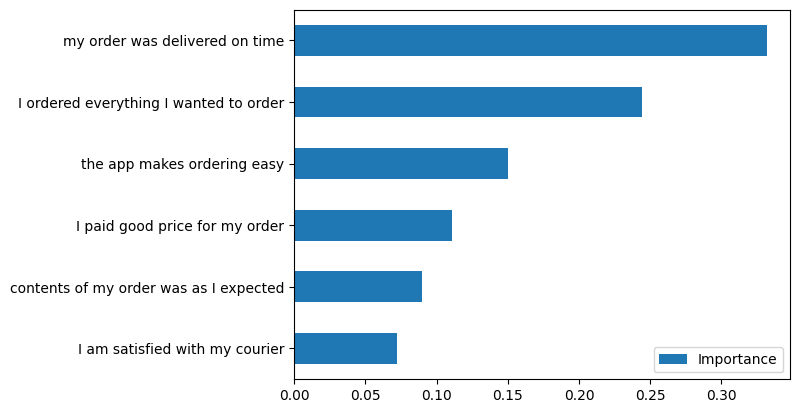

In [26]:
best_coef_df.plot(kind='barh')
plt.show()

### Random Forest and Bagging

This section utilizes ensemble methods whereby using mulitple trees to agregate a decision in the splitting of node leaves. The main different between the two methods of this section are the max_features used. In the case of Bagging the max_features will equal the number of predictors form the dataset.

A Random Forest model will be utilized also but will only utilize the square root of the number of predictors (√6 = 2.45). We will try 2 and 3 for the bagging method.

In [49]:
# Bagging

rf = RandomForestClassifier(max_features=X_train.shape[1],
                            max_depth=4,
                            n_estimators=3000,
                            random_state=seed,
                            criterion='entropy',
                            bootstrap=True)
rf

RandomForestClassifier(criterion='entropy', max_depth=4, max_features=6,
                       n_estimators=3000, random_state=5249)

In [50]:
rf.fit(X_train, y_train)

return_scores(rf, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.820000,0.836364,0.836364
Test,0.538462,0.357143,0.625000


In [51]:
from hpsklearn import HyperoptEstimator, any_classifier, any_preprocessing
import hyperopt
from hyperopt import hp, Trials, fmin, STATUS_OK

space = {
    'n_estimators': hp.choice('n_estimators', np.arange(100,5000,250)),
    'max_depth': hp.choice('max_depth', [2,3,4])
}

def hyperparameter_tuning(space):
    model = RandomForestClassifier(
        max_features=X_train.shape[1],
        n_estimators=space['n_estimators'],
        max_depth=space['max_depth'],
        random_state=seed
        )
    # evaluation = [(X_train_gauss, y_train_gauss), (X_test_gauss, y_test_gauss)]

    model.fit(X_train, y_train)
    
    acc = model.score(X_test, y_test)   
    
    print()
    print(return_scores(model, X_train, X_test, y_train, y_test))
    print({'n_estimators': space['n_estimators'],
           'max_depth': space['max_depth']})

    return {'loss': -acc, 'status': STATUS_OK}

In [52]:
trials = Trials()

best = fmin(fn=hyperparameter_tuning,
            space=space,
            algo=hyperopt.tpe.suggest,
            trials=trials,
            max_evals=50,
            verbose=0)

print(f"\nBest hyperparameter sweep: \n\t{best}")


       Accuracy    Recall  Precision
Train  0.720000  0.672727   0.787234
Test   0.538462  0.285714   0.666667
{'n_estimators': np.int64(1350), 'max_depth': 2}

       Accuracy    Recall  Precision
Train  0.830000  0.854545   0.839286
Test   0.538462  0.428571   0.600000
{'n_estimators': np.int64(3600), 'max_depth': 4}

       Accuracy    Recall  Precision
Train  0.830000  0.854545   0.839286
Test   0.576923  0.428571   0.666667
{'n_estimators': np.int64(600), 'max_depth': 4}

       Accuracy    Recall  Precision
Train  0.790000  0.763636      0.840
Test   0.538462  0.357143      0.625
{'n_estimators': np.int64(2100), 'max_depth': 3}

       Accuracy    Recall  Precision
Train  0.780000  0.763636   0.823529
Test   0.538462  0.357143   0.625000
{'n_estimators': np.int64(1100), 'max_depth': 3}

       Accuracy    Recall  Precision
Train  0.720000  0.672727   0.787234
Test   0.538462  0.285714   0.666667
{'n_estimators': np.int64(1600), 'max_depth': 2}

       Accuracy    Recall  Precisi

In [53]:
rf_tuned = RandomForestClassifier(max_features=X_train.shape[1],
                                  max_depth=4,
                                  n_estimators=2500,
                                  criterion='entropy',
                                  random_state=seed).fit(X_train, y_train)

return_scores(rf_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.820000,0.836364,0.836364
Test,0.538462,0.357143,0.625000


In [54]:
# Random Forest

rf_2 = RandomForestClassifier(max_features=2,
                              max_depth=4,
                              random_state=seed,
                              bootstrap=False,
                              criterion='entropy')

In [55]:
rf_2.fit(X_train, y_train)

return_scores(rf_2, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.77,0.745455,0.820000
Test,0.50,0.357143,0.555556


In [56]:
rf_2_tuned = RandomForestClassifier(
    max_features=2,
    n_estimators=3000,
    max_depth=4,
    random_state=seed,
    bootstrap=False, 
    criterion='entropy').fit(X_train, y_train)

return_scores(rf_2_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.76,0.745455,0.803922
Test,0.50,0.357143,0.555556


In [57]:
## for a test split of 20% the rf_tuned model worked best. With 50% it was the decision tree

best_coef_df = pd.DataFrame({
    'Importance': rf_tuned.feature_importances_
}, index=X_train.columns).sort_values('Importance', ascending=True)

best_coef_df

,Importance
I paid good price for my order,0.113619
the app makes ordering easy,0.129346
contents of my order was as I expected,0.132594
I ordered everything I wanted to order,0.189182
I am satisfied with my courier,0.193193
my order was delivered on time,0.242065


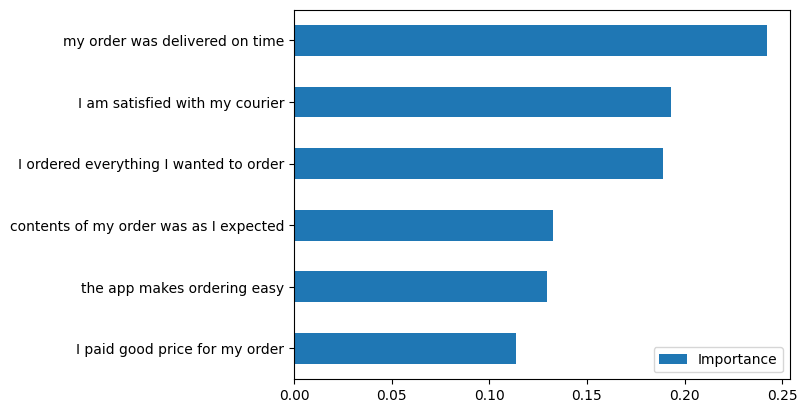

In [58]:
best_coef_df.plot(kind='barh')
plt.show()

In [74]:
import pathlib

path = pathlib.Path('../../feature importances/bagging_features.csv')

if path.exists() != True:
    best_coef_df.to_csv(path)

In [59]:
return_scores(best_, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.73,0.690909,0.791667
Test,0.50,0.285714,0.571429


In [60]:
return_scores(rf_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.820000,0.836364,0.836364
Test,0.538462,0.357143,0.625000


In [61]:
return_scores(rf_2_tuned, X_train, X_test, y_train, y_test)

,Accuracy,Recall,Precision
Train,0.76,0.745455,0.803922
Test,0.50,0.357143,0.555556


Experimenting with different tree based models we can see that using a bagging method via the RandomForest model performed best, but still did not outperform the logistic regression model.

The RandomForest model alone does not perform due to the fact that the number of predictors is small (6) and that not many of the predictors are correlated to each other. (Intro to Statistical Learning p.347)